In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cosmolopy.distance as cd
import cosmolopy.constants as cc
import afterglowpy as grb
import pandas as pd
from scipy.interpolate import interp1d
from scipy import interpolate
from scipy.integrate import quad
from astropy.time import Time
from astropy.cosmology import Planck18 as cosmo

In [2]:
import sys
sys.path.append('/home/masson/afterglowpy')
from orphan_modules.tools import mag_to_flux

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Compute SN1998bw light curve 

It is expected that SNe associated with long GRBs are very similar to SN1998bw (the first SN associated to a GRB). The flux of the supernova (in mJy) is saved in the `sn_flux.txt` file for each of the filter U, B, V, R and I.

In [4]:
file = '/home/masson/orphans/data/sn_flux.txt'
df_sn = pd.read_table(file, sep=' ', header=2, names=['t[days]', 'U', 'B', 'V', 'R', 'I'])
df_sn

,t[days],U,B,V,R,I
0,8.510,3.736,7.248,8.771,7.187,5.40
1,10.430,4.925,8.020,10.440,8.561,6.37
2,12.430,5.253,8.794,11.670,9.562,7.05
3,13.430,5.302,9.041,11.990,9.920,7.38
4,15.360,5.501,9.124,12.790,10.580,7.88
5,19.500,3.912,7.520,11.770,10.670,7.95
6,21.490,3.165,6.549,10.740,10.290,7.80
7,22.450,2.887,5.918,10.160,10.010,7.59
8,23.410,2.468,5.202,9.618,9.650,7.38
9,24.340,2.210,4.833,9.270,9.387,7.32


In [5]:
def sn_light_curve(df_sn, freq, z):
    """ Compute supernova light curve based on SN1998bw

    :param freq: frequency in Hz for which we want to compute the flux
    :returns: t: time in days used for the calculations
    :returns: fzlist: list containing the corresponding flux in mJy
    """

    # cosmological parameters used
    cosmo = {'omega_M_0' : 0.315, 'omega_lambda_0' : 0.685, 'h' : 0.673}
    cosmo = cd.set_omega_k_0(cosmo)
    H0 = 100*cosmo['h']
    #print('\nPlanck cosmological parameters used: \nomega_M_0 = 0.315, omega_lambda_0 = 0.685, H0 = 67.3 km/s/Mpc\n')

    # redshift of the GRB progenitor
    #z = 0.05

    dL_GRB = cd.luminosity_distance(z, **cosmo)
    dL_98bw = cd.luminosity_distance(0.0085, **cosmo)   # reference is SN1998bw, of redshift z = 0.0085

    # wavelength corresponding to the frequency for which we want to compute the flux
    wave15 = 299792458 / freq

    # frequency calculated in the rest-frame of the SN
    freq_rest = freq * (1+z) / 1.0085
    freq_rest_small = freq_rest * 1e-15
    wave_rest = 299792458 / freq_rest

    # normalisation constant to rescale the flux of the SN1998bw to match the GRB progenitor redshift
    norm = ((1+z) / 1.0085) * (dL_98bw/dL_GRB)**2

    # polynomial degree for SED fitting (2,3,4), *N=2 recommended!!!*)
    N = 2 


    ### SEDS (BRUTE FORCE FOR NOW...) ###
    ### USING LCS FROM CLOCCHIATI ET AL. 2011, APJ, 
    ## TIMES - OBSERVER-FRAME IN DAYS FOR SN 1998bw (z=0.0085) ###
    t = df_sn['t[days]']


    ### REDSHIFTED TIMES ###
    tz = [] # REDSHIFTED TIMES
    for i in t:
        n = i * ((1+z) / 1.0085)
        tz.extend(['%.3f' %n])


    ### SEDS - FREQUENCIES ###
    ### USING WAVE_EFF -> FREQ EFF FROM FUKUGITA 1995 ###
    ### [U,B,V,R,I] in Hz
    filters = ['U', 'B', 'V', 'R', 'I']
    x = [0.821e+15, 0.684e+15, 0.550e+15, 0.468e+15, 0.375e+15]

    ### FLUXES (mJy)
    fzlist = []
    
    for i in range(len(df_sn)):
        
        y = [df_sn.iloc[i]['U'], df_sn.iloc[i]['B'], df_sn.iloc[i]['V'], df_sn.iloc[i]['R'], df_sn.iloc[i]['I']]
        f = np.poly1d(np.polyfit(x, y, N+1))
        fz = f(freq_rest) * norm
        fzlist.append(fz)
    
    return t, fzlist

/tmp/ipykernel_19743/133026430.py:17: RuntimeWarning: invalid value encountered in log10
  magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6


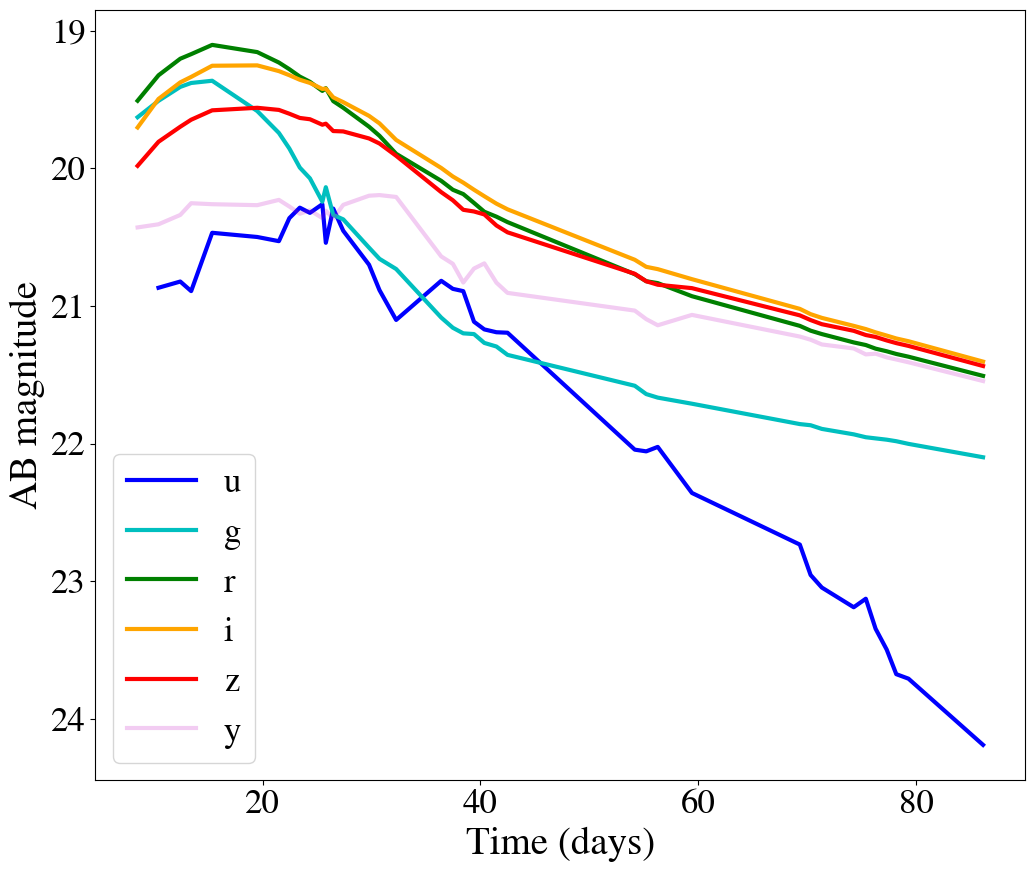

In [6]:
# plot the SN light curve
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(12,10))

nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
             298760145396604.1] 
filters = ['u', 'g', 'r', 'i', 'z', 'y']
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

#z = 0.0085
z = 0.1

for nu, c, f in zip(nu_lsst, colors, filters):
    
    magzlist = []
    t, fzlist = sn_light_curve(df_sn, nu, z)
    magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6
    
    if f == 'y':
        #plt.scatter(t, magzlist, color=c, label=f, s=30, alpha=0.2)
        plt.plot(t, magzlist, color=c, alpha=0.2, lw=3, label=f)
        
    else:
        #plt.scatter(t, magzlist, color=c, label=f, s=30)
        plt.plot(t, magzlist, color=c, lw=3, label=f)
    
plt.xlabel('Time (days)', fontsize=28)
plt.ylabel('AB magnitude', fontsize=28)
plt.gca().invert_yaxis()
plt.legend()

#plt.savefig('../figures/sn_lc.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Plot SN1998bw and an orphan light curves on the same figure

In [7]:
# computing orphan GRB afterglow light curve
config = {'jetType':     grb.jet.PowerLaw,     # Jet Type
          'specType':    0,                  # Emission Spectrum
          'b':           4,       # Power Law index
          'thetaObs':    0.3,     # Viewing angle in radians
          'E0':          1.0e53,  # Isotropic-equivalent energy in erg
          'thetaWing':   0.1,    # Truncation angle in radians
          'thetaCore':   0.05,     # Half-opening angle in radians
          'n0':          1.0,     # Circumburst density in cm^{-3}
          'p':           2.2,     # Electron energy distribution index
          'epsilon_e':   0.1,     # epsilon_e
          'epsilon_B':   0.01,    # epsilon_B
          'xi_N':        1.0,     # Fraction of electrons accelerated
          'd_L':         cosmo.luminosity_distance(0.1).value * 3.08e24,  # Luminosity distance in cm
          'z':           0.1}    # Redshift


#t = np.geomspace(1.0e3, 1.0e7, 300)
nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
             298760145396604.1] 
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

mag_grb = [[]]*6
t_grb = np.linspace(1., 95, 100)

for i, nu in enumerate(nu_lsst):
    
    Fnu = grb.fluxDensity(t_grb * grb.day2sec, nu, **config)*1.0e-3
    mag_grb[i] = -2.5 * np.log10(Fnu*1.0e-23) - 48.6 

/tmp/ipykernel_19743/2517621109.py:10: RuntimeWarning: invalid value encountered in log10
  magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6


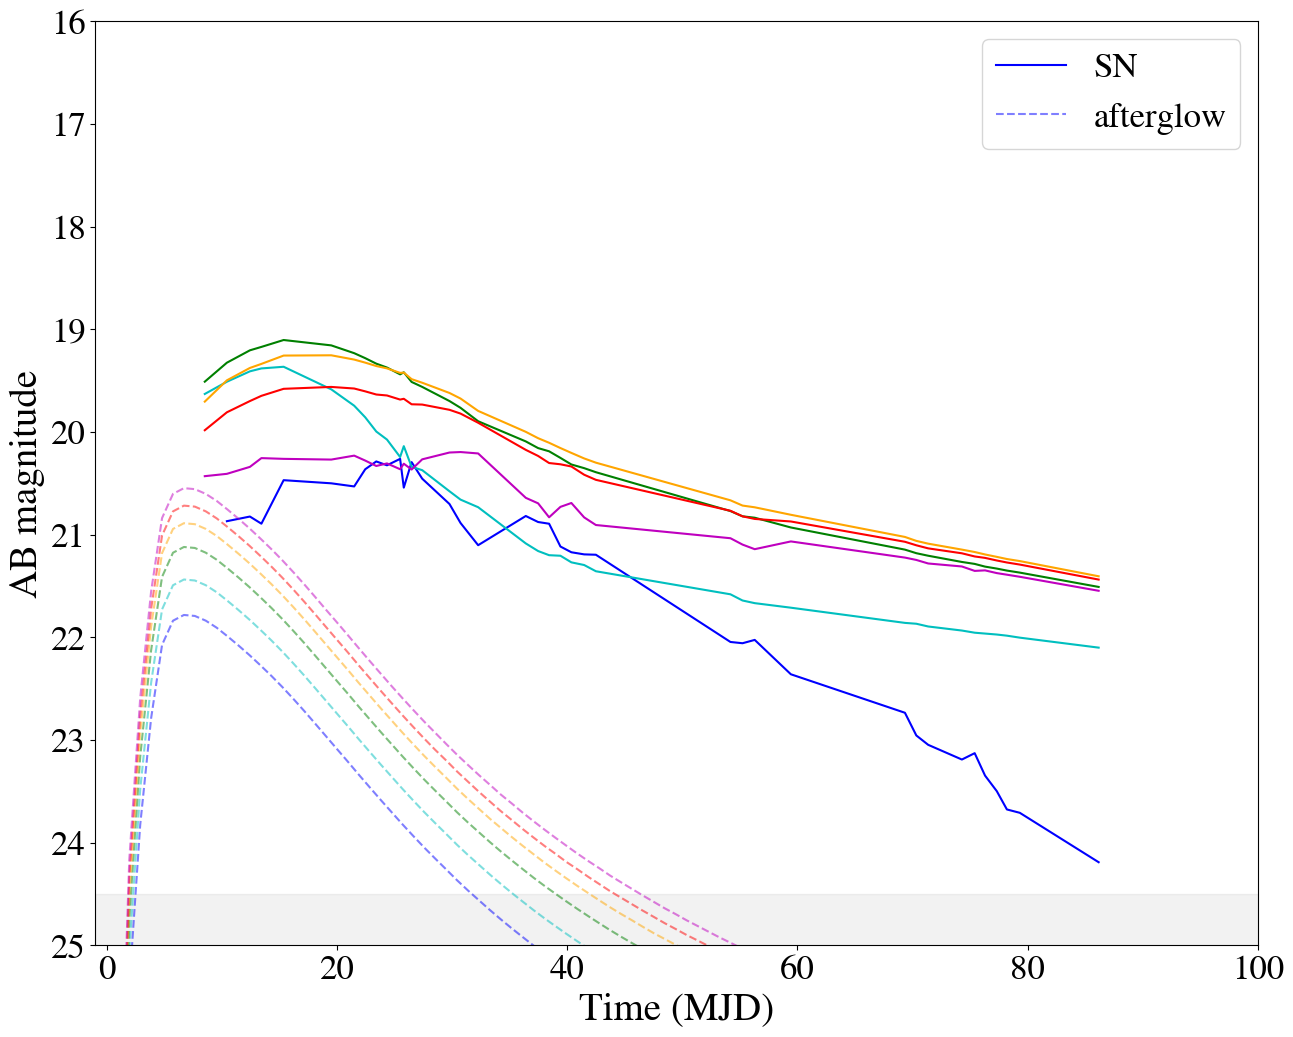

In [8]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(15,12))

#T0 = Time(62114.62630306261, format='mjd', scale='utc')

for i, (nu, c) in enumerate(zip(nu_lsst, colors)):
    
    magzlist = []
    t, fzlist = sn_light_curve(df_sn, nu, z)
    magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6
    
    if i == 0:
        plt.plot(t, magzlist, color=c, label='SN')
        plt.plot(t_grb, mag_grb[i], color=c, alpha=0.5, ls='--', label='afterglow')
        
    else:
        plt.plot(t, magzlist, color=c)
        plt.plot(t_grb, mag_grb[i], color=c, ls='--', alpha=0.5)
        
    
plt.fill_between([-1, 1e3], 24.5, 31., color='k', alpha=0.05)
plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=28)
plt.ylabel('AB magnitude', fontsize=28)
#plt.xscale('log')
plt.xlim(-1, 100)
plt.ylim(25, 16)
plt.legend()

## We can found more data at later times for SN1998bw...

In [9]:
df_sn_complete =  pd.read_fwf('../data/sn1998bw_complete_lc.txt', sep=' ', header=2, 
                              names=['Full', 'JD', 't[days]', 'U', 'Uerr', 'B', 'Berr', 'V', 'Verr', 'R', 
                                     'Rerr', 'I', 'Ierr'])
df_sn_complete.fillna(0)

,Full,JD,t[days],U,Uerr,B,Berr,V,Verr,R,Rerr,I,Ierr
0,2,939,9.5,14.04,0.04,14.25,0.06,13.86,0.06,13.91,0.06,13.95,0.01
1,3,940,10.5,13.91,0.06,14.16,0.01,13.76,0.03,13.80,0.05,13.87,0.01
2,4,941,11.5,13.83,0.02,14.10,0.01,13.67,0.01,13.72,0.02,13.80,0.01
3,5,942,12.5,13.78,0.03,14.05,0.01,13.61,0.01,13.64,0.01,13.75,0.01
4,6,943,13.5,13.75,0.04,14.02,0.01,13.56,0.03,13.59,0.02,13.70,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,491,1428,494.4,0.00,0.00,23.14,0.01,22.78,0.03,22.33,0.01,22.26,0.04
490,492,1429,495.4,0.00,0.00,23.15,0.01,22.79,0.03,22.34,0.01,22.28,0.05
491,493,1430,496.4,0.00,0.00,23.16,0.01,22.80,0.03,22.36,0.01,22.30,0.06
492,494,1431,497.4,0.00,0.00,23.18,0.01,22.81,0.04,22.37,0.01,22.31,0.05


/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)


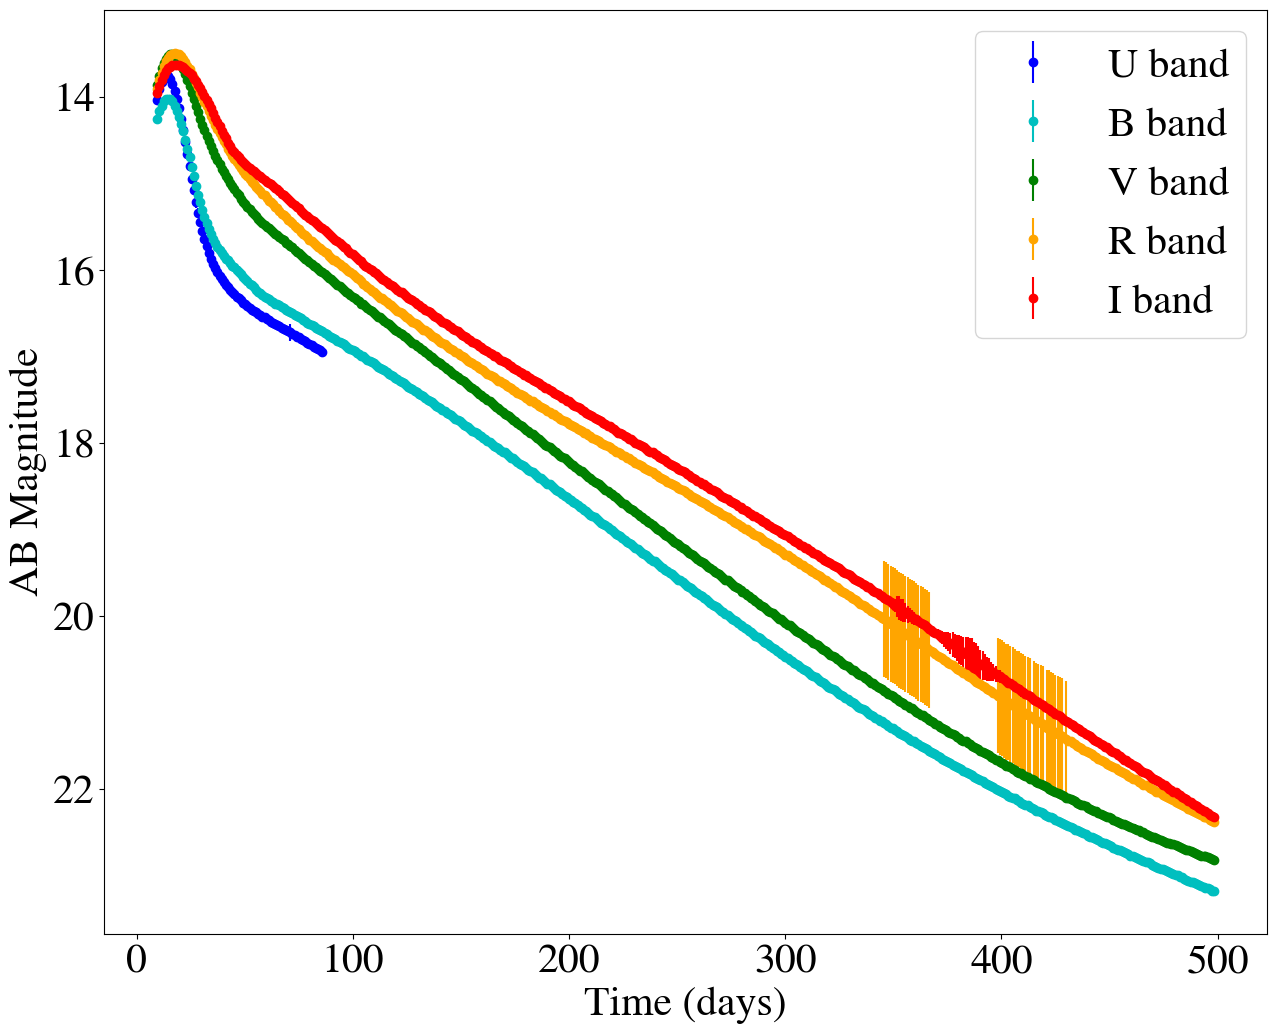

In [10]:
plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

plt.errorbar(df_sn_complete['t[days]'], df_sn_complete['U'], yerr=df_sn_complete['Uerr'], fmt='o', label='U band', c='b')
plt.errorbar(df_sn_complete['t[days]'], df_sn_complete['B'], yerr=df_sn_complete['Berr'], fmt='o', label='B band', c='c')
plt.errorbar(df_sn_complete['t[days]'], df_sn_complete['V'], yerr=df_sn_complete['Verr'], fmt='o', label='V band', c='g')
plt.errorbar(df_sn_complete['t[days]'], df_sn_complete['R'], yerr=df_sn_complete['Rerr'], fmt='o', label='R band', c='orange')
plt.errorbar(df_sn_complete['t[days]'], df_sn_complete['I'], yerr=df_sn_complete['Ierr'], fmt='o', label='I band', c='r')
plt.gca().invert_yaxis()
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.legend()
plt.show()

In [11]:
def sn_light_curve_BVRI(df_sn, freq, z):
    """ Compute supernova light curve based on SN1998bw

    :param freq: frequency in Hz for which we want to compute the flux
    :returns: t: time in days used for the calculations
    :returns: fzlist: list containing the corresponding flux in mJy
    """

    # cosmological parameters used
    cosmo = {'omega_M_0' : 0.315, 'omega_lambda_0' : 0.685, 'h' : 0.673}
    cosmo = cd.set_omega_k_0(cosmo)
    H0 = 100*cosmo['h']
    #print('\nPlanck cosmological parameters used: \nomega_M_0 = 0.315, omega_lambda_0 = 0.685, H0 = 67.3 km/s/Mpc\n')

    # redshift of the GRB progenitor
    #z = 0.05

    dL_GRB = cd.luminosity_distance(z, **cosmo)
    dL_98bw = cd.luminosity_distance(0.0085, **cosmo)   # reference is SN1998bw, of redshift z = 0.0085

    # wavelength corresponding to the frequency for which we want to compute the flux
    wave15 = 299792458 / freq

    # frequency calculated in the rest-frame of the SN
    freq_rest = freq * (1+z) / 1.0085
    freq_rest_small = freq_rest * 1e-15
    wave_rest = 299792458 / freq_rest

    # normalization constant to rescale the flux of the SN1998bw to match the GRB progenitor redshift
    norm = ((1+z) / 1.0085) * (dL_98bw/dL_GRB)**2

    # polynomial degree for SED fitting (2,3,4), *N=2 recommended!!!*)
    N = 2 


    ### SEDS (BRUTE FORCE FOR NOW...) ###
    ### USING LCS FROM CLOCCHIATI ET AL. 2011, APJ, 
    ## TIMES - OBSERVER-FRAME IN DAYS FOR SN 1998bw (z=0.0085) ###
    t = df_sn['t[days]']


    ### REDSHIFTED TIMES ###
    tz = [] # REDSHIFTED TIMES
    for i in t:
        n = i * ((1+z) / 1.0085)
        tz.extend(['%.3f' %n])


    ### SEDS - FREQUENCIES ###
    ### USING WAVE_EFF -> FREQ EFF FROM FUKUGITA 1995 ###
    ### [U,B,V,R,I] in Hz
    filters = ['B', 'V', 'R', 'I']
    x = [0.684e+15, 0.550e+15, 0.468e+15, 0.375e+15]

    ### FLUXES (mJy)
    fzlist = []
    
    for i in range(len(df_sn)):
        
        y = [mag_to_flux(np.array(df_sn.iloc[i]['B'])), mag_to_flux(np.array(df_sn.iloc[i]['V'])), 
             mag_to_flux(np.array(df_sn.iloc[i]['R'])), mag_to_flux(np.array(df_sn.iloc[i]['I']))]
        f = np.poly1d(np.polyfit(x, y, N+1))
        fz = f(freq_rest) * norm
        fzlist.append(fz)
    
    return t, fzlist

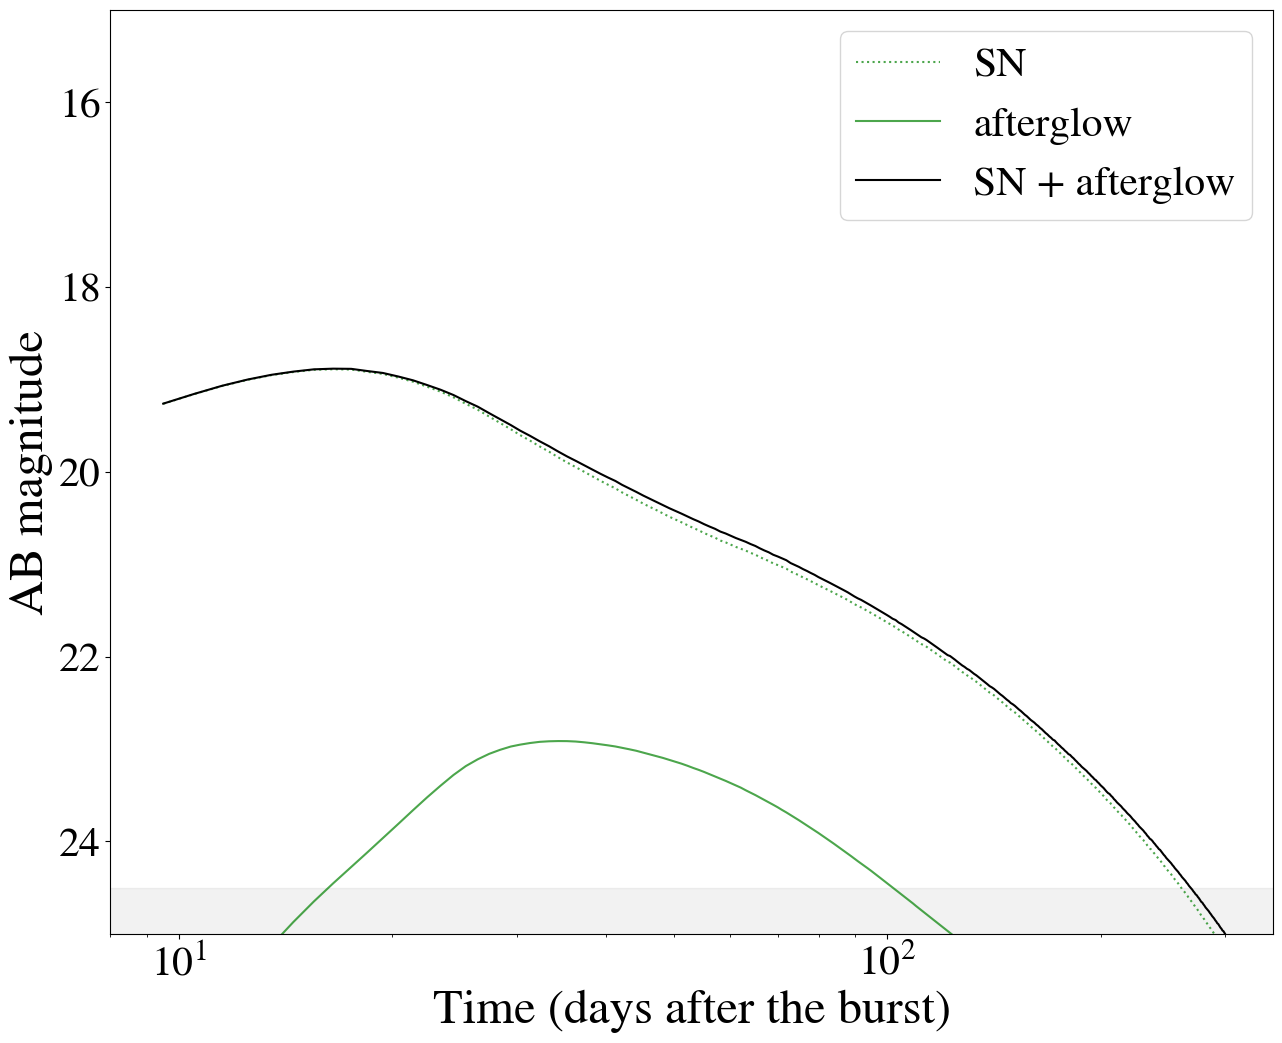

In [12]:
z = 0.1

# computing orphan GRB afterglow light curve
config = {'jetType':     grb.jet.PowerLaw,     # Jet Type
          'specType':    0,                  # Emission Spectrum
          'b':           4,       # Power Law index
          'thetaObs':    0.5,     # Viewing angle in radians
          'E0':          1.0e53,  # Isotropic-equivalent energy in erg
          'thetaWing':   0.15,    # Truncation angle in radians
          'thetaCore':   0.1,     # Half-opening angle in radians
          'n0':          1.0,     # Circumburst density in cm^{-3}
          'p':           2.2,     # Electron energy distribution index
          'epsilon_e':   0.1,     # epsilon_e
          'epsilon_B':   0.01,    # epsilon_B
          'xi_N':        1.0,     # Fraction of electrons accelerated
          'd_L':         cosmo.luminosity_distance(z).value * 3.08e24,  # Luminosity distance in cm
          'z':           z}    # Redshift


t_grb = np.geomspace(1e-3, 9.5, 100)

# we consider here only (u, g, r, i, z) as y may be not accurate
nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56] 
colors = ['b', 'c', 'g', 'orange', 'r']


plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

#T0 = Time(62114.62630306261, format='mjd', scale='utc')

for i, (nu, c) in enumerate(zip(nu_lsst, colors)):
    
    t, fzlist = sn_light_curve_BVRI(df_sn_complete, 482703137570394.2, z)
    magzlist = -2.5 * np.log10(np.array(fzlist)*1.0e-26) - 48.6
    
    #Fnu_early = grb.fluxDensity(t_grb * grb.day2sec, nu, **config)*1.0e-3
    #mag_grb_early = -2.5 * np.log10(Fnu_early*1.0e-23) - 48.6 
    
    Fnu = grb.fluxDensity(t * grb.day2sec, nu, **config)*1.0e-3
    mag_grb = -2.5 * np.log10(Fnu*1.0e-23) - 48.6 
    
    mag_tot_late = -2.5 * np.log10((Fnu + np.array(fzlist)*1.0e-3)*1.0e-23) - 48.6
    
    t_tot = np.concatenate([t_grb[t_grb<5.], t])
    #mag_tot = np.concatenate([mag_grb_early[t_grb<5.], mag_tot_late])
    
    if i == 2:
        plt.plot(t, magzlist, color=c, alpha=0.7, ls=':', label='SN')
        #plt.plot(t_grb, mag_grb_early, color=c, alpha=0.7)
        plt.plot(t, mag_grb, color=c, alpha=0.7, label='afterglow')
        plt.plot(t, mag_tot_late, color='k', label='SN + afterglow')
        
    #else:
        #plt.plot(t, magzlist, alpha=0.5, ls=':', color=c)
        #plt.plot(t, mag_grb, color=c, ls='--', alpha=0.3)
        #plt.plot(t, mag_tot, color=c)
        
    
plt.fill_between([-1e3, 1e3], 24.5, 31., color='k', alpha=0.05)
plt.gca().invert_yaxis()
plt.xlabel('Time (days after the burst)', fontsize=35)
plt.ylabel('AB magnitude', fontsize=35)
plt.xscale('log')
plt.xlim(8, 350)
plt.ylim(25, 15)
plt.legend()

#plt.savefig('../figures/sn+oa_lc_far.pdf', format="pdf", bbox_inches="tight", transparent=True)